# 📊 FinDataMining
Notebook 03: **Modelado**

---

## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from category_encoders import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score
from src.transform import obtener_cols_financieras, obtener_cols_flag
from src.config import clean_data_file
from src.modeling import *

In [2]:
# Abrir archivo clean_data
df = pd.read_parquet(clean_data_file)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32242 entries, 3 to 35309
Data columns (total 79 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   CashAndCashEquivalents                 32242 non-null  float64       
 1   CurrentDebt                            32242 non-null  float64       
 2   LongTermDebt                           32242 non-null  float64       
 3   TotalDebt                              32242 non-null  float64       
 4   StockholdersEquity                     32242 non-null  float64       
 5   TotalAssets                            32242 non-null  float64       
 6   CurrentAssets                          32242 non-null  float64       
 7   CurrentLiabilities                     32242 non-null  float64       
 8   TotalNoncurrentLiabilities             32242 non-null  float64       
 9   TotalLiabilities                       32242 non-null  float64    

## Feature Engineering

In [3]:
# Celda reservada para probar la creación de variables en la fase de modelado.


## Modelo de ensamblado de árboles RandomForest

In [ ]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores

# Columnas Financieras: las columnas originales del balance. No son predictores, las mantuve para poder incluirlas en el reporte final
cols_financieras = obtener_cols_financieras()

# Columnas flag: las quito por su baja relevancia
cols_flag = obtener_cols_flag(df)

# Excluir las variables que tengan baja importancia para reducir el ruido
variables_no_significativas = [
    'FreeCashFlow_TTM_QoQ',
    'CapitalExpenditure_TTM_QoQ',
    'AverageDailyVolume_Lag1_Acceleration',
    'AverageDailyVolume_Lag1_QoQ_Yeo',
    'CapitalExpenditure_TTM_YoY',
    'CapExToRevenue_Log1p',
    'Industry',

]

predictores_a_eliminar = cols_financieras + cols_flag + variables_no_significativas + [
    # Variable objetivo
    'MonthlyExcessReturn_Quantile',
    'Target_Top_Quintile',

    # Variables de volumen y precios crudos: 
    # No tiene sentido utilizarlas habiendo multiples tickers
    'Open',
    'Close',    
    'AverageDailyVolume_Lag1',

    # Otros
    'Ticker',
    'FinancialsSource'
    ]

# Se define la variable objetivo (categórica)
label = 'Target_Top_Quintile'

# Se separan los datos pasados de los del mes actual
# X_train / y_train: Todos los meses históricos completamente cerrados
# X_live / _ : El mes actual en curso (y_test se ignora porque es inválido)
X_train, X_live, y_train, _ = split_ultimo(df, label=label, cols_excluded=predictores_a_eliminar)

# Se configuran las columnas para el pipeline
columnas_agrupacion = ['Date', 'Sector']

# Numéricas: Cualquier variable numérica que no sea Date o Sector
columnas_num = [col for col in X_train.select_dtypes(include=np.number).columns if col not in columnas_agrupacion]

# Categóricas: Todas las categorías aislando Date
columnas_cat = [col for col in X_train.select_dtypes(exclude=np.number).columns if col != 'Date']

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', CrossSectionalScaler(groupby_cols=columnas_agrupacion, features=columnas_num), 
        # Se envian las numéricas y de agrupación, el escalador devolverá sólo las numéricas.
        columnas_num + columnas_agrupacion),
    ('cat', OneHotEncoder(), columnas_cat)
])

# Pipeline del modelo
pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=30,
        min_samples_split= 50,
        max_samples= 0.3,
        max_features=0.25,
        class_weight='balanced'        
        ))
])

print("Entrenando el modelo clasificador con datos históricos completos...")
pipe.fit(X_train, y_train)

# Predicciones sobre el set de entrenamiento
y_train_pred = pipe.predict(X_train)

# Calcular la métrica de Precisión
precision_entrenamiento = precision_score(y_train, y_train_pred)
print(f"Entrenamiento finalizado. Precision en histórico: {precision_entrenamiento:.4f}")

Entrenando el modelo clasificador con datos históricos completos...
Entrenamiento finalizado. Precision en histórico: 0.2674


In [5]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X_train, 
    y=y_train, 
    cv=tscv,         
    scoring='precision',
    n_jobs=-1        
)

print(f"Precision promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

Precision promedio Time Series CV: 0.2594 ± 0.0128


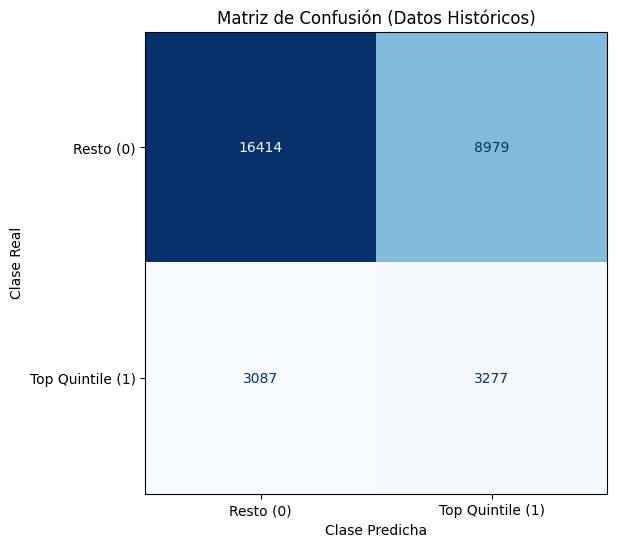

In [6]:
# Matriz de confusión
mostrar_matriz_confusion(y_train, y_train_pred)

In [7]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(25)

,feature,importance
26,num__Variance_Yeo,0.208494
10,num__ShortTermBeta,0.056529
22,num__ProfitMargins_Yeo,0.050021
13,num__MarketCap_Log1p,0.048716
15,num__TotalRevenue_TTM_QoQ_Yeo,0.039841
3,num__AssetToMarket,0.039456
21,num__OperatingMargins_Yeo,0.038001
23,num__ReturnOnAssets_Yeo,0.033790
4,num__NetDebtToEbitda,0.032358
2,num__RevenueYield,0.031293


In [8]:
# Variables menos significativas
feature_importance_df.tail(20)

,feature,importance
5,num__FreeCashFlow_TTM_YoY,0.017712
8,num__FreeCashFlow_TTM_Acceleration,0.017291
17,num__TotalRevenue_TTM_YoY_Yeo,0.017047
16,num__FcfToEbitda_Yeo,0.015031
18,num__AverageDailyVolume_Lag1_YoY_Yeo,0.014221
12,num__CurrentRatio_Log1p,0.014173
11,num__DebtToEquity_Log1p,0.013028
27,num__CapExToRevenue_Log1p,0.012592
9,num__CapitalExpenditure_TTM_Acceleration,0.008637
32,cat__Sector_2,0.006107


In [9]:
# Visualizar distribución de features
X_train.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,31757,2023-09-16 10:49:03.527411200,2021-01-01 00:00:00,2022-05-01 00:00:00,2023-09-01 00:00:00,2025-02-01 00:00:00,2026-06-01 00:00:00,NaN
YearsInSP500,31757.0,14.449381,0.0,0.0,5.0,23.0,69.0,19.971606
EbitdaYield,31757.0,0.090122,-1.292356,0.05099,0.076799,0.116611,1.4031,0.10681
RevenueYield,31757.0,0.773041,-2.0,0.232162,0.47653,0.955228,7.5,0.89091
AssetToMarket,31757.0,1.463499,0.001536,0.496607,0.926024,1.777015,15.416756,1.591274
NetDebtToEbitda,31757.0,2.154087,-15.495987,0.63051,1.774121,3.326923,19.302838,3.176602
FreeCashFlow_TTM_YoY,31757.0,0.347986,-7.526435,-0.250621,0.03,0.413124,8.09583,1.840551
TotalRevenue_TTM_Acceleration,31757.0,-0.064818,-1.363345,-0.097848,-0.03581,0.006844,1.30766,0.178488
EBITDA_TTM_Acceleration,31757.0,-0.137165,-5.682749,-0.188011,-0.043199,0.059231,5.550846,0.849966
FreeCashFlow_TTM_Acceleration,31757.0,-0.221325,-8.650107,-0.395521,-0.029444,0.225801,8.313115,2.102352


## Aplicación del modelo

In [10]:
# Aplicar predicciones sobre los datos recientes
resultados_agrupados, tickers_test = generar_ranking_predicciones(
    pipe=pipe, 
    X_live=X_live, 
    df=df
)

# Imprimir los 10 primeros resultados
print(resultados_agrupados.head(10).to_string(index=False))

Ticker  Predicted_Class  Probability_Top       Signal
    MU                1         0.639516 Top_Quantile
   XRX                1         0.639373 Top_Quantile
  TROX                1         0.622091 Top_Quantile
   ADV                1         0.614482 Top_Quantile
  JELD                1         0.613211 Top_Quantile
    GO                1         0.607190 Top_Quantile
  SNEX                1         0.606837 Top_Quantile
   AMN                1         0.601191 Top_Quantile
   NWL                1         0.599276 Top_Quantile
  SMCI                1         0.597994 Top_Quantile


In [11]:
# Se genera el reporte final para research posterior
df_reporte = generar_reporte(df, resultados_agrupados)
df_reporte.head()

Reporte exportado en la carpeta de datos.


,Ticker,Predicted_Class,Probability_Top,Signal,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,StockholdersEquity,TotalAssets,...,ProfitMargins_Yeo,ReturnOnAssets_Yeo,ReturnOnEquity_Yeo,EnterpriseValue_Yeo,Variance_Yeo,Target_Top_Quintile,CapExToRevenue_Log1p,BookToMarket_Yeo,EarningsYield_Yeo,AccrualsRatio_Yeo
0,MU,1,0.639516,Top_Quantile,24995.000,3324.000,3052.000,6376.000,100724.000,134112.000,...,3.716122,3.958177,0.029259,3.755917,3.150332,0,0.242865,-1.118982,-0.038787,0.410125
1,XRX,1,0.639373,Top_Quantile,585.000,165.000,4281.000,4446.000,513.000,9902.000,...,-1.336530,-1.673195,-0.272448,-0.402677,3.130346,0,0.012338,1.771297,-5.000000,-1.018895
2,TROX,1,0.622091,Top_Quantile,126.000,172.000,3124.000,3464.000,1289.000,6057.000,...,-1.414222,-1.430416,-0.092357,-0.401753,2.968179,0,0.097176,1.761147,-3.164599,-0.497320
3,ADV,1,0.614482,Top_Quantile,143.870,25.865,1520.790,1546.655,478.028,2564.850,...,-0.987363,-1.587097,-0.111452,-0.433384,3.161543,0,0.013612,1.180120,-3.063720,-1.278457
4,JELD,1,0.613211,Top_Quantile,50.361,19.526,1189.436,1406.767,12.181,2077.268,...,-1.425931,-2.673436,-1.445022,-0.440589,3.127727,0,0.037322,-1.060677,-5.000000,-2.438161


## Explicabilidad del Modelo (SHAP)

--- Explicación de la probabilidad de ser Quintil 1 para: XRX ---


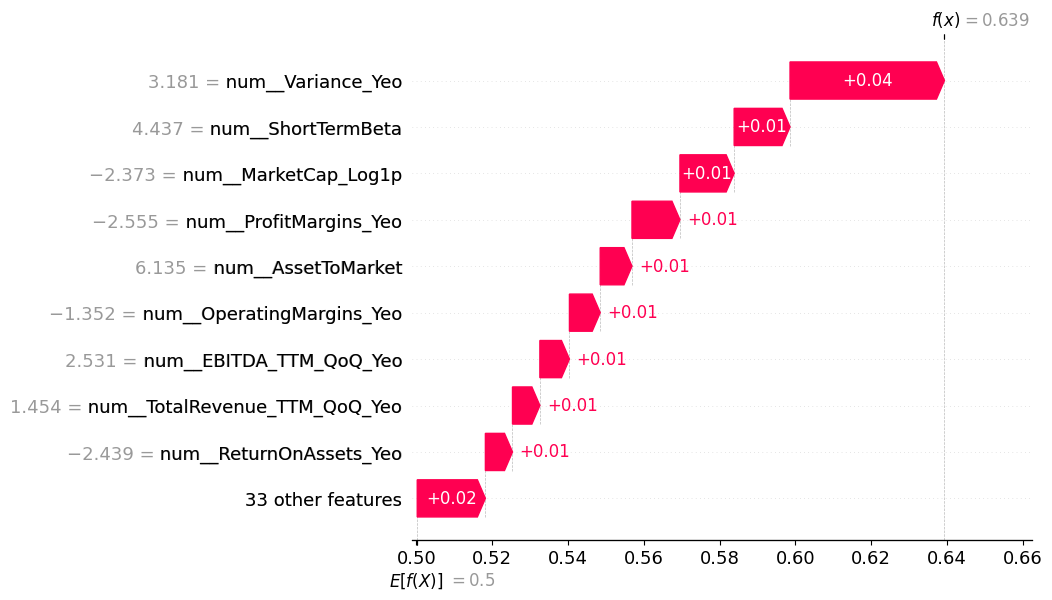

In [12]:
graficar_explicacion_shap(
    ticker_a_explicar='XRX', # Indicar un Ticker a evaluar
    pipe=pipe, 
    X_live=X_live, 
    tickers=tickers_test
)

## Anexo: optimización de hiper-parámetros

In [13]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest Classifier"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el clasificador
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestClassifier(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [4],
        'rf__min_samples_leaf': [30],
        'rf__min_samples_split': [50],
        'rf__max_samples': [0.3],
        'rf__max_features': [0.25],
        'rf__class_weight': ['balanced']
    }

    # Configurar el GridSearchCV con la métrica correcta
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='precision',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X_train, y_train)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)